<a href="https://colab.research.google.com/github/AgatheHeriard-Dubreuil/AgatheHeriard-Dubreuil-DataScience-GenAI-Submissions/blob/main/InClassTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First I use Gemini to import the data and visualise the first few rows of the dataframe. I use the prompt: "Create a data frame with the csv file in_class_test(in).csv and show the first 5 rows"

In [ ]:
import pandas as pd

df = pd.read_csv('in_class_test(in).csv')
display(df.head())

,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,50.331,120.4,111.2,130.9,177.7,162.5,194.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
1,Afghanistan,1990,Female,51.442,114.2,105.1,124.7,173.1,158.0,189.7,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
2,Afghanistan,1990,Male,49.281,126.2,116.4,137.5,182.0,166.6,199.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
3,Afghanistan,1991,Both sexes,50.999,116.8,108.2,126.2,171.7,157.6,186.9,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28
4,Afghanistan,1991,Female,52.119,110.7,102.1,120.4,167.1,153.0,182.6,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28


This output looks good, it is what I wanted. By looking at the first few rows of the data frame, i can determine which variables to analyse and what their types are. First I will start by conducting a univariate analysis of a numerical variable, then of a categorical one. (With more time I would do this for more variables). For the numerical data I will analyse Life Expectancy. However, there are very few categorical variables that would give interesting information, so I will only do a numerical variable analysis.

For the numerical univaraite analysis, I will calculate the mean, median, mode of the data. Then I will also calulate the standard deviation, the variance and the Interquartile range. Finally, I will visualise the data using a histogram and a boxlot. I will use the code from the gihub to calculate these :https://github.com/MJMortensonWarwick/IB2AD0_Data_Science_GenerativeAI/blob/main/3_0X_Statistical_Exploratory_Data_Analysis.ipynb

In [ ]:
print("Life Expectancy")
print(f"Mean Life Expectancy: {round(df['Life Expectancy'].mean(),2)}")
print(f"Median Life Expectancy: {round(df['Life Expectancy'].median(),2)}")
print(f"Mode Life Expectancy: {round(df['Life Expectancy'].mode()[0],2)}")

Life Expectancy
Mean Life Expectancy: 69.01
Median Life Expectancy: 71.13
Mode Life Expectancy: 71.06


In [ ]:
print("Life Expectancy")
print(f"Std Dev Life Expectancy: {round(df['Life Expectancy'].std(),2)}")
print(f"Variance Life Expectancy: {round(df['Life Expectancy'].var(),2)}")
q1_LE = df['Life Expectancy'].quantile(0.25)
q3_LE = df['Life Expectancy'].quantile(0.75)
iqr_LE = q3_LE - q1_LE
print(f"IQR Life Expectancy: {round(iqr_LE,2)} (Q1: {round(q1_LE,2)}, Q3: {round(q3_LE,2)})")
print(f"Range Life Expectancy: {round(df['Life Expectancy'].max() - df['Life Expectancy'].min(),2)}")

Life Expectancy
Std Dev Life Expectancy: 9.69
Variance Life Expectancy: 93.93
IQR Life Expectancy: 13.17 (Q1: 63.08, Q3: 76.25)
Range Life Expectancy: 62.91


We can see that the variance for Life Expectancy is very large and that the mean is lower than the median and mode. This suggests that there are very low values that bring down the average. Indeed, the IQR is quite small compared to the variance.  By visualising the data with a boxplot, we will be able to see all this information in more detail. We do this using Gemini with the prompt: "create a boxplot and a histoplot for the variable Life Expectancy from the data frame"

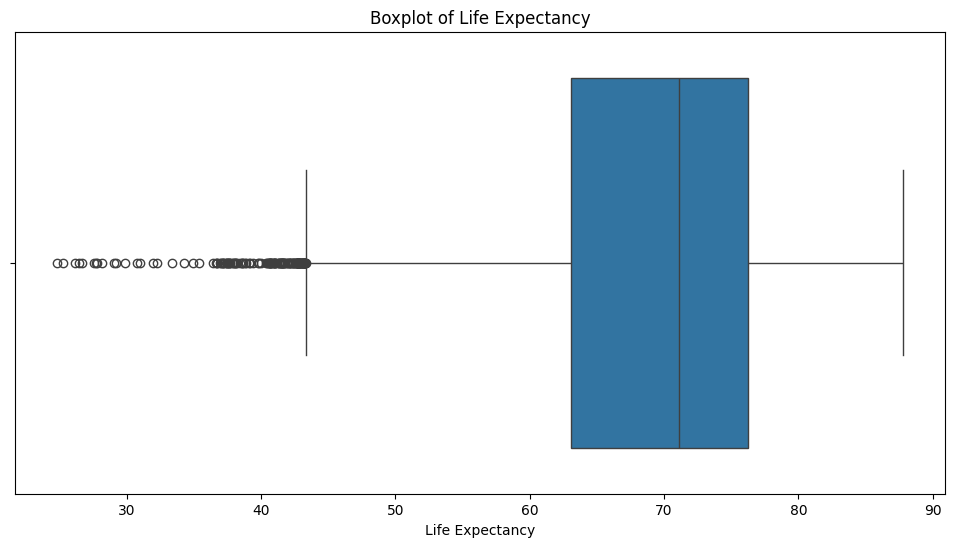

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Life Expectancy'])
plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.show()

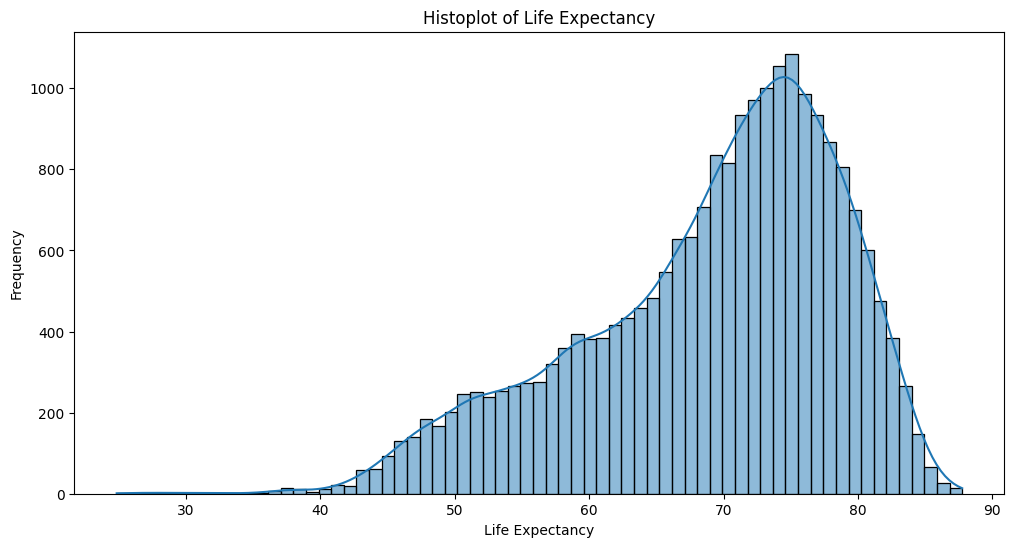

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Life Expectancy'], kde=True)
plt.title('Histoplot of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

The output from Gemini is what I exected it to be, the code is good. These plots further confirm my observation that there are many statistical outliers in the data (for lower values), which we can see on the boxplot> This is also shown on the Histplot where we see a long tail in the beginning.

Now, we move on to bivariate analysis. Because of a lack of time we will only do 2 bivariate analyses: we will compare Life Expectancy with
Tobacco Prevalence and Infant Mortality rate with Country. For Infant Mortality rate with Country since we have numerical data and categorical data we will calculate group-wise statistics and then make volin plots to visualise the data. For Life Expectancy with
Tobacco Prevalence , I will make calculate Pearson Correlation Coefficient and Spearman Rank corr coeff. Then, I will make Scatterplots to visualise the data.

Starting with  Infant Mortality rate and Country . For the group-wise statistics I will use the code from the github page :https://github.com/MJMortensonWarwick/IB2AD0_Data_Science_GenerativeAI/blob/main/3_0X_Statistical_Exploratory_Data_Analysis.ipynb

In [ ]:
print("Infant Mortality rate by Country")
print(df.groupby('Country')['Infant Mortality Rate'].agg(['mean', 'median', 'std']).reset_index().round(2))

Infant Mortality rate by Country
            Country   mean  median    std
0       Afghanistan  79.49   78.05  22.63
1            Africa    NaN     NaN    NaN
2           Albania  19.31   18.16   9.37
3           Algeria  29.57   29.06   7.29
4    American Samoa    NaN     NaN    NaN
..              ...    ...     ...    ...
276  Western Sahara    NaN     NaN    NaN
277           World    NaN     NaN    NaN
278           Yemen    NaN     NaN    NaN
279          Zambia    NaN     NaN    NaN
280        Zimbabwe    NaN     NaN    NaN

[281 rows x 4 columns]


We see there are a lot of missing values, so perhaps (with more time) it would be better to remove the missing values from this table. We do however see significant differences in different countries infant mortality rate, which is to be expected.  I will now use Gemini to make violin plots, that will give us more information on the distributions and possible outliers. I use the prompt: "From the data frame, create a violin plot of Infant mortality rate by Country"

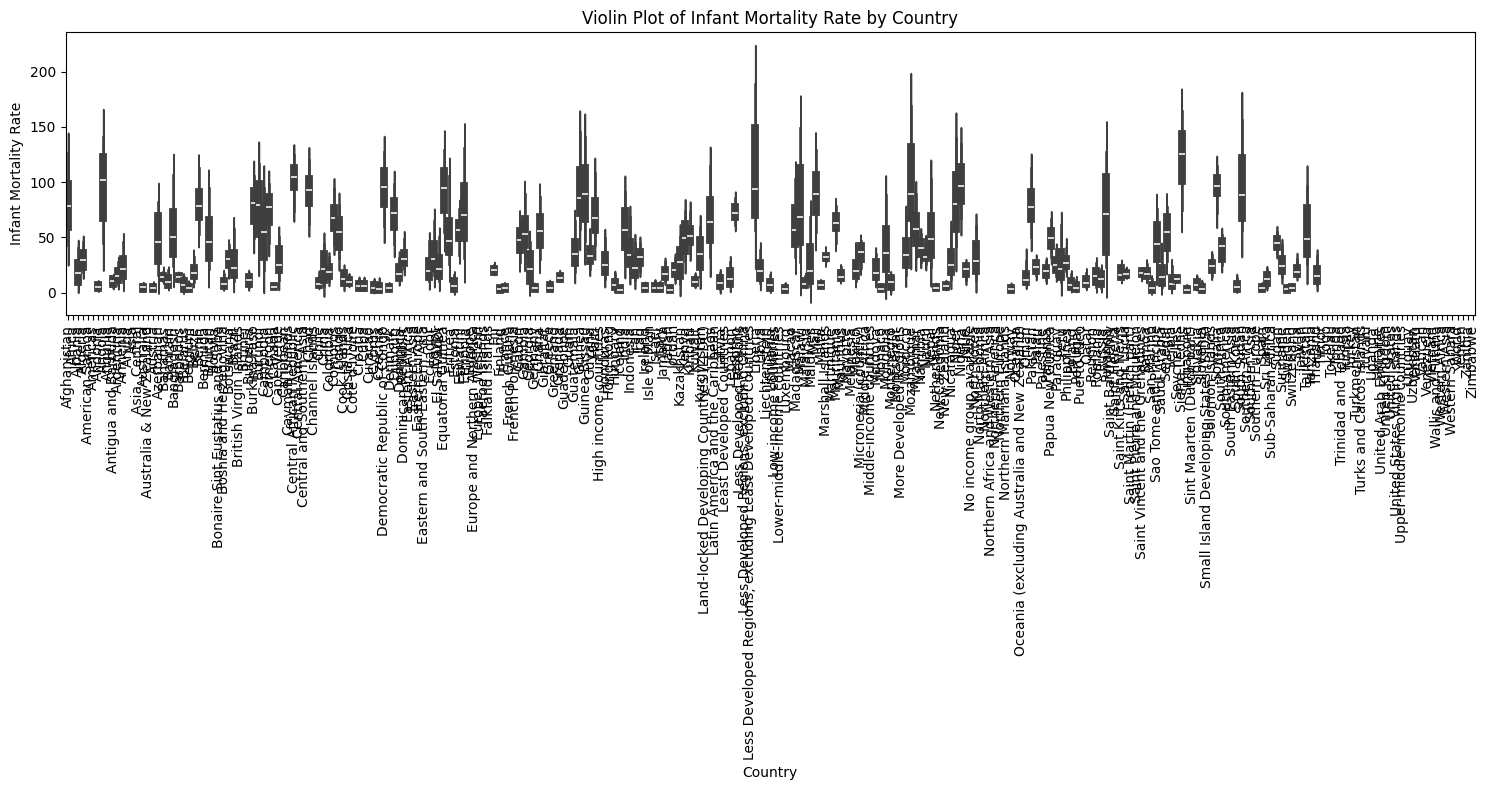

In [ ]:
plt.figure(figsize=(15, 8))
sns.violinplot(x='Country', y='Infant Mortality Rate', data=df)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.title('Violin Plot of Infant Mortality Rate by Country')
plt.xlabel('Country')
plt.ylabel('Infant Mortality Rate')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

This violin plot visualizes the distribution of 'Infant Mortality Rate' for each 'Country'. The width of each violin indicates the density of observations at different 'Infant Mortality Rate' values. The thick bar inside represents the interquartile range (IQR), the thin line extends to show the rest of the distribution, and the dot in the middle is the median. Due to the high number of countries, the plot might appear crowded, but it still provides insights into the spread and central tendency of infant mortality rates across different nations.

The plot is too crowded so i will ask Gemini to make another one with just the first 5 countries alphabetically: "From the data frame, create a violin plot of Infant mortality rate by Country for the first 5 countries in the data frame that do not have missing values"

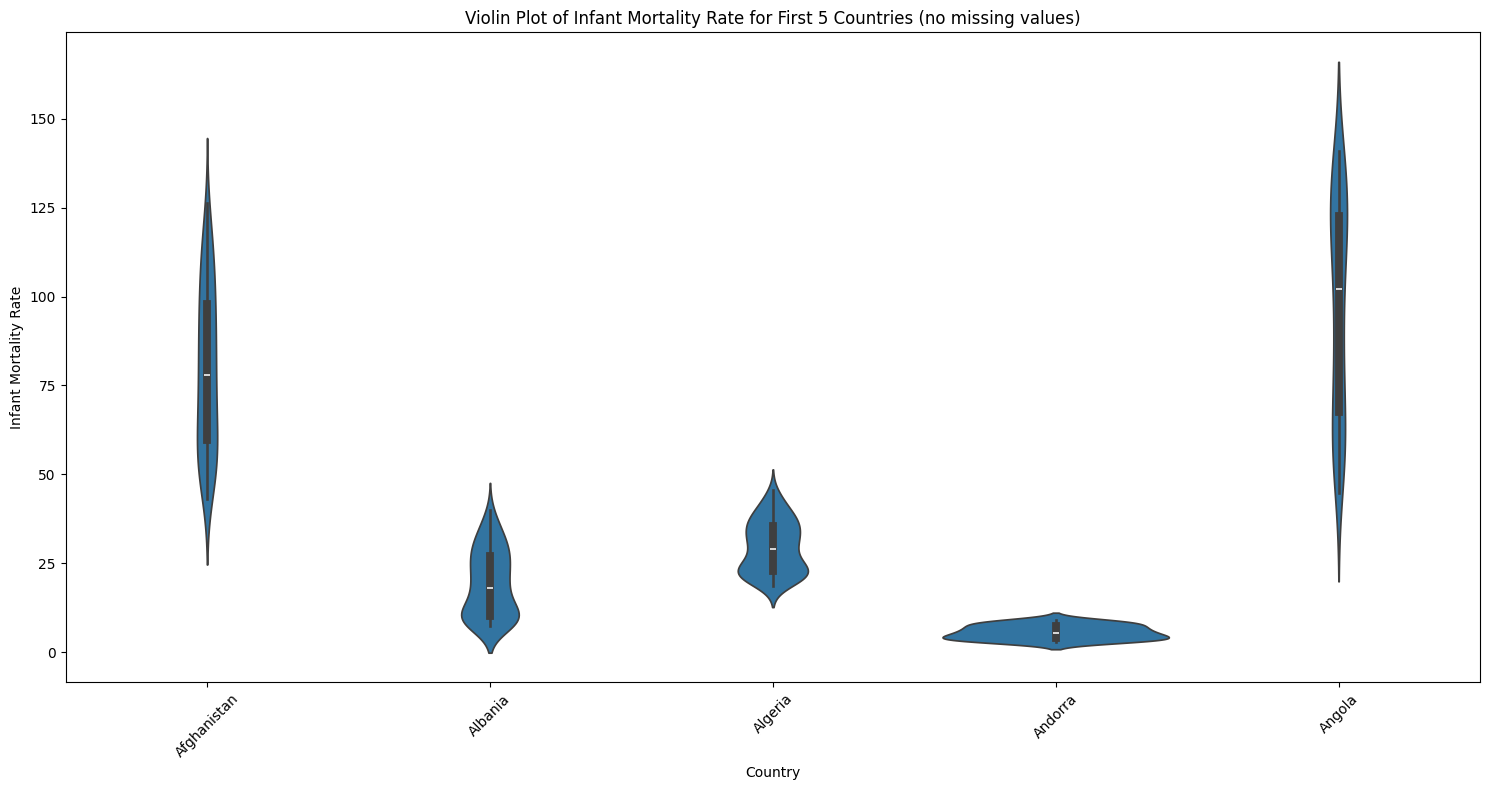

In [ ]:
df_no_nan = df.dropna(subset=['Infant Mortality Rate'])
first_5_countries_no_nan = df_no_nan['Country'].unique()[:5]
df_filtered_no_nan = df_no_nan[df_no_nan['Country'].isin(first_5_countries_no_nan)]

plt.figure(figsize=(15, 8))
sns.violinplot(x='Country', y='Infant Mortality Rate', data=df_filtered_no_nan)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.title('Violin Plot of Infant Mortality Rate for First 5 Countries (no missing values)')
plt.xlabel('Country')
plt.ylabel('Infant Mortality Rate')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

This output is what I excpected from gemini, the code is good. From this we can see that for countries like Albania, Algeria and Andorra the Infant mortality rate is very low and there are no outliers visible on the plot. However, for Afghanista and Angola the infant mortality rate is much higher in average and has much more varaince.

because of a lack of time I will not conduct the bivariate analysis of Life Expectancy and Tobacco Prevalence. With time I would have calculated Pearson Correlation Coefficient and Spearman Rank corr coeff. Then, I would make Scatterplots to visualise the data. We can expect that these would be somewhat postively correlated.

Now, we move on to Multivariate analysis.

For the Multivariate analysis we do not have time to make multiple plots so i will make a one seaborn.pairplot with the variables:
Life Expectancy, Suicides Rate, Alcohol Abuse,
Infant Mortality Rate coloured by Gender.
I will use Gemini with the prompt: "create a seaborn.pairplot with the variables:
Life Expectancy, Suicides Rate, Alcohol Abuse,
Infant Mortality Rate coloured by Gender. from the data frame"
I will check the code Gemini outputs and compare it to the one in the GIthub

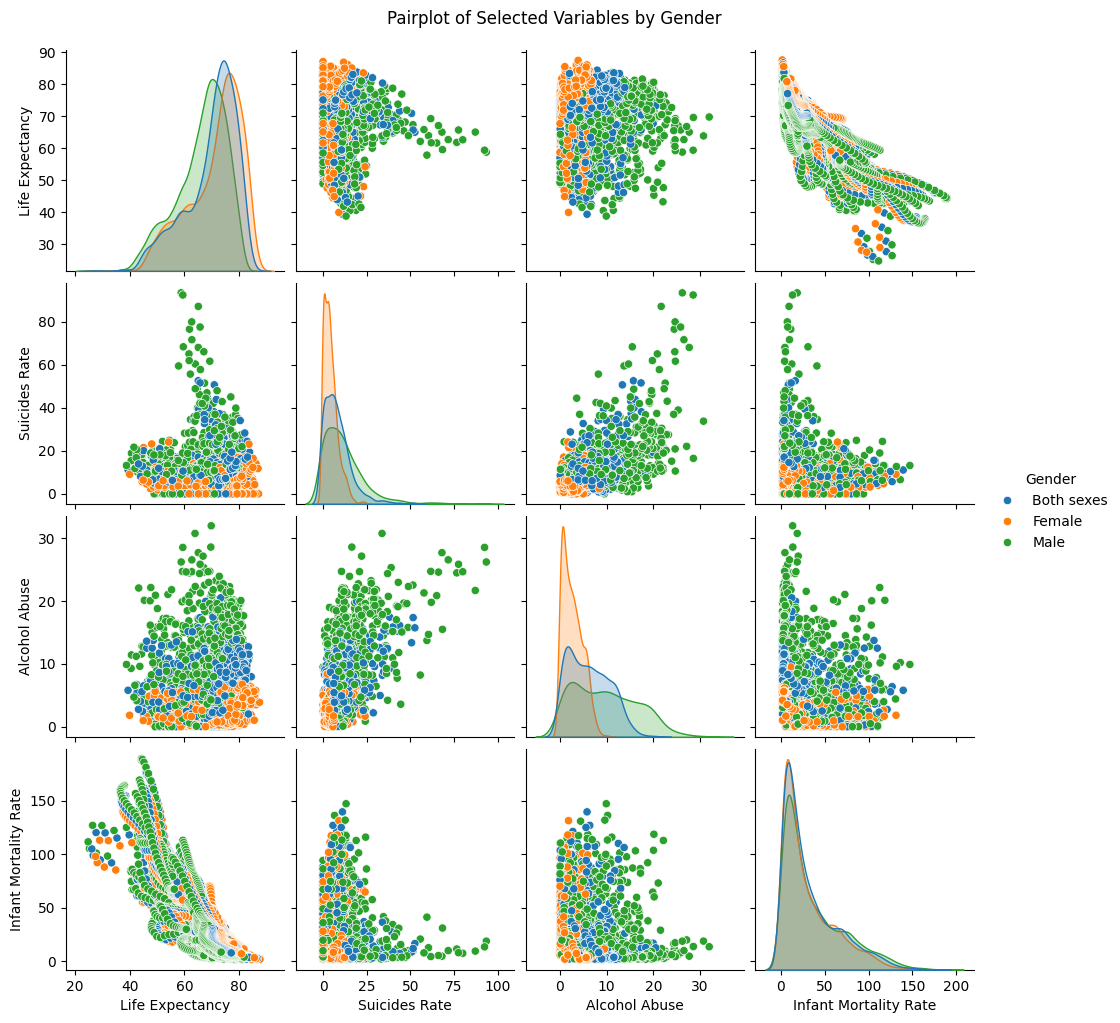

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['Life Expectancy', 'Suicides Rate', 'Alcohol Abuse', 'Infant Mortality Rate']

sns.pairplot(df, vars=variables, hue='Gender')
plt.suptitle('Pairplot of Selected Variables by Gender', y=1.02) # Adjust suptitle position
plt.show()

Now we will identify outliers in the data. For this we will use the IQR method for outlier detection. Normally, I would do this for all the numerical values, but because of time I will only do it for one of them : Under 5 Mortality rate. using the code from the github:https://colab.research.google.com/github/MJMortensonWarwick/IB2AD0_Data_Science_GenerativeAI/blob/main/3_0X_Statistical_Exploratory_Data_Analysis.ipynb#scrollTo=R7BeXMkRgXVh

We'did not have time identified the exact values that were flagged as outliers in the box plots. Now, a human data scientist would investigate these.

Finally, we will identify missing values using a heatmap . I will use the code from github.https://colab.research.google.com/github/MJMortensonWarwick/IB2AD0_Data_Science_GenerativeAI/blob/main/3_0X_Statistical_Exploratory_Data_Analysis.ipynb#scrollTo=R7BeXMkRgXVh

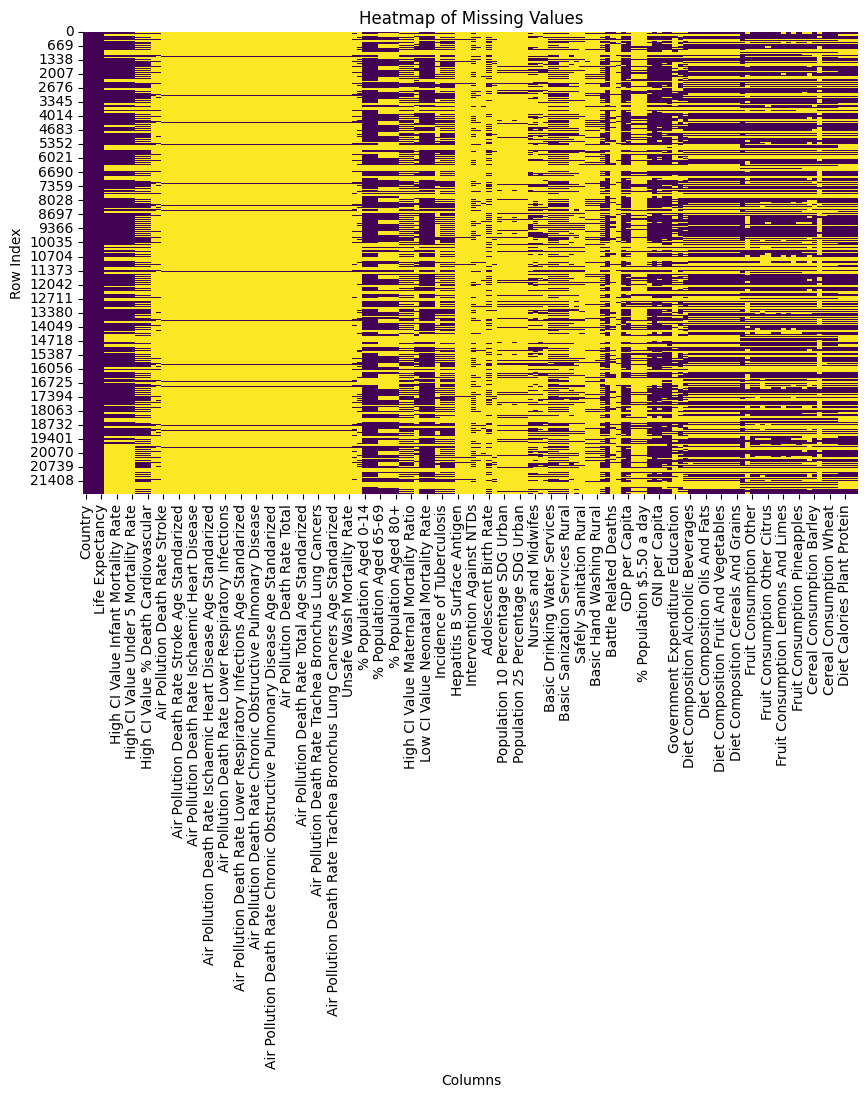

--- Percentage of Missing Values ---
Country                          0.000000
Year                             0.000000
Gender                           0.000000
Life Expectancy                  0.000000
Infant Mortality Rate           34.435374
                                  ...    
Cereal Consumption Rice         41.197279
Diet Calories Animal Protein    45.224490
Diet Calories Plant Protein     45.224490
Diet Calories Fat               45.224490
Diet Calories Carbohydrates     45.224490
Length: 150, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.ylabel('Row Index')
plt.xlabel('Columns')
plt.show()

print("--- Percentage of Missing Values ---")
print(df.isnull().sum() / len(df) * 100)